In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_classification, make_circles


# Clasificación con el Iris Dataset
El **Iris dataset** contiene 150 observaciones de flores con 4 características.
Hay 3 clases: *setosa*, *versicolor* y *virginica*.

## 1. Cargar el Iris dataset desde sklearn

In [38]:
from sklearn import datasets

iris = datasets.load_iris()
print(type(iris))
print('Claves disponibles:', iris.keys())

<class 'sklearn.utils._bunch.Bunch'>
Claves disponibles: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


## 2. Construir el DataFrame

In [39]:
# Crear DataFrame con los datos y nombres de columnas
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Agregar columna target (0=setosa, 1=versicolor, 2=virginica)
df['Target'] = iris.target

print('Shape:', df.shape)
df.head()

Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Cambiar el nombre de las columnas a PascalCase

In [40]:
# Transformar nombres de columnas a PascalCase (código del lab)
columns_name = [''.join([c.capitalize() for c in col.split()]) for col in df.columns]
columns_name = [col.replace('(', '_') for col in columns_name]
cols         = [col.replace(')', '')  for col in columns_name]

df.columns = cols
print('Columnas renombradas:')
print(df.columns.tolist())
df.head()

Columnas renombradas:
['SepalLength_cm', 'SepalWidth_cm', 'PetalLength_cm', 'PetalWidth_cm', 'Target']


,SepalLength_cm,SepalWidth_cm,PetalLength_cm,PetalWidth_cm,Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 4. Analizar el DataFrame: nulos, cantidad de datos, descripción

In [41]:
print(f'Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}')

Filas: 150  |  Columnas: 5


In [42]:
# Información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SepalLength_cm  150 non-null    float64
 1   SepalWidth_cm   150 non-null    float64
 2   PetalLength_cm  150 non-null    float64
 3   PetalWidth_cm   150 non-null    float64
 4   Target          150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [43]:
# Conteo de valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nTotal de nulos: {df.isnull().sum().sum()}')

Valores nulos por columna:
SepalLength_cm    0
SepalWidth_cm     0
PetalLength_cm    0
PetalWidth_cm     0
Target            0
dtype: int64

Total de nulos: 0


In [44]:
# Estadísticas descriptivas
df.describe().round(3)

,SepalLength_cm,SepalWidth_cm,PetalLength_cm,PetalWidth_cm,Target
count,150.000,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199,1.000
std,0.828,0.436,1.765,0.762,0.819
min,4.300,2.000,1.000,0.100,0.000
25%,5.100,2.800,1.600,0.300,0.000
50%,5.800,3.000,4.350,1.300,1.000
75%,6.400,3.300,5.100,1.800,2.000
max,7.900,4.400,6.900,2.500,2.000


In [45]:
# Descripción del dataset (texto del lab)
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

## 5. Estadística básica y gráficas exploratorias

In [46]:
# Conteo por clase
print('Distribución de clases:')
print(df['Target'].value_counts())
print('\nNombres de clases:', list(iris.target_names))

Distribución de clases:
Target
0    50
1    50
2    50
Name: count, dtype: int64

Nombres de clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


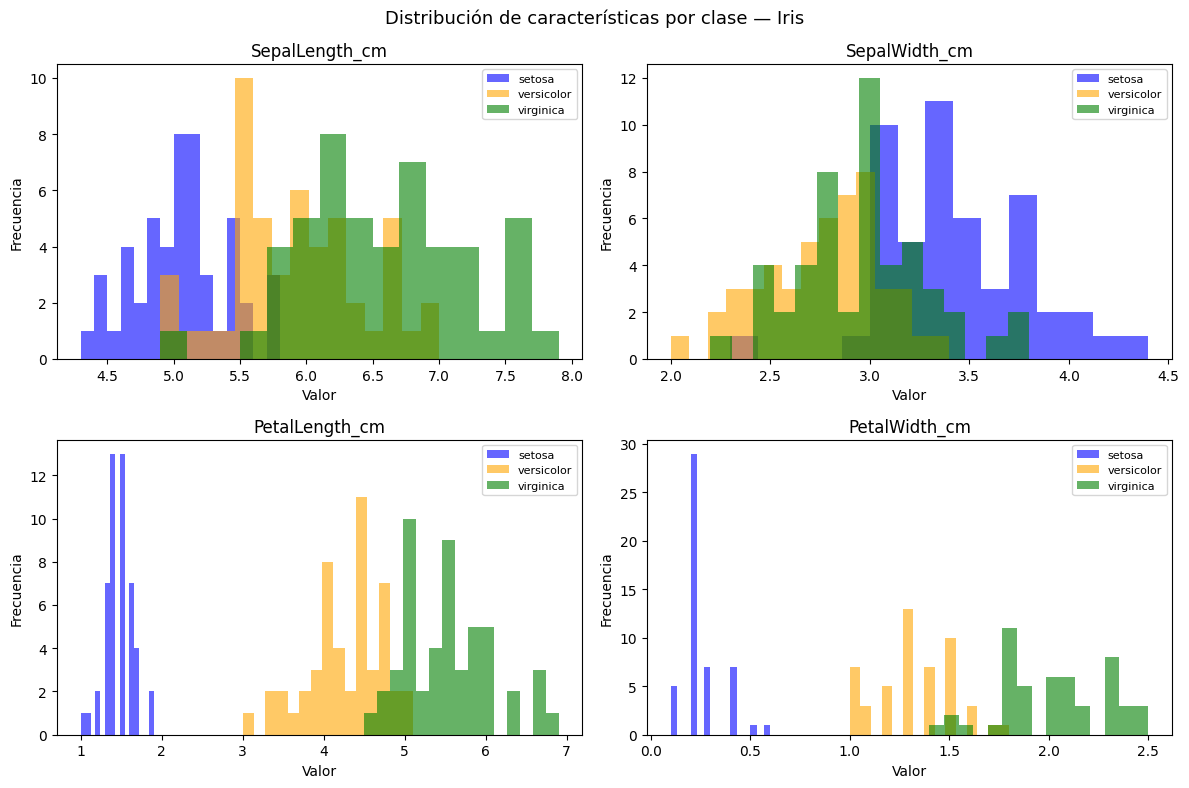

In [47]:
# Histogramas por característica
cols_features = [c for c in df.columns if c != 'Target']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols_features):
    for clase, color, nombre in [(0, 'blue', 'setosa'),
                                  (1, 'orange', 'versicolor'),
                                  (2, 'green', 'virginica')]:
        axes[i].hist(df[df['Target'] == clase][col], bins=15,
                     alpha=0.6, color=color, label=nombre)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de características por clase — Iris', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Matriz de correlación con heatmap

In [48]:
# Matriz de correlación (código del lab: df.corr())
corr_matrix = df.corr()
print('Correlaciones con Target (ordenadas):')
print(corr_matrix['Target'].sort_values(ascending=False).round(3))

Correlaciones con Target (ordenadas):
Target            1.000
PetalWidth_cm     0.957
PetalLength_cm    0.949
SepalLength_cm    0.783
SepalWidth_cm    -0.427
Name: Target, dtype: float64


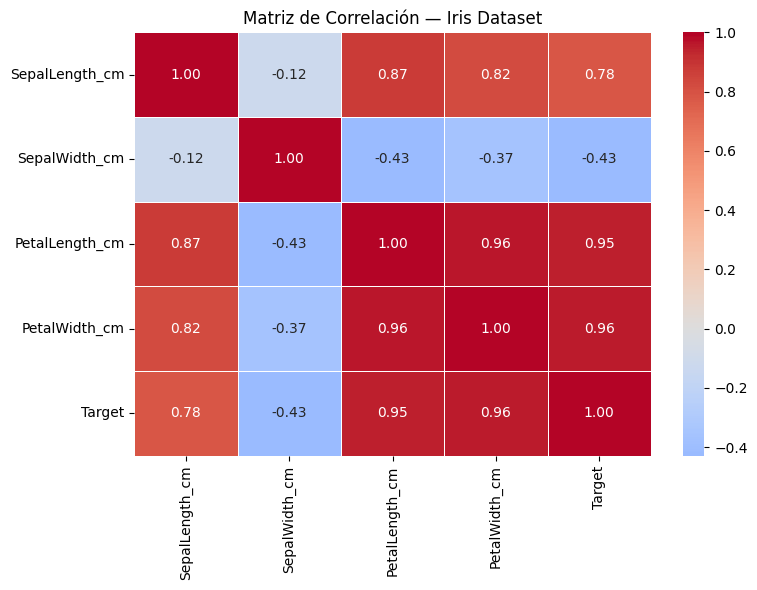

In [49]:
# Heatmap de la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, annot_kws={'size': 10})
plt.title('Matriz de Correlación — Iris Dataset')
plt.tight_layout()
plt.show()

## 7. Separar datos en Train y Test con StratifiedShuffleSplit

Se usa el **muestreo estratificado** para garantizar que la proporción de clases sea igual en train y test.

In [50]:
from sklearn.model_selection import StratifiedShuffleSplit

# Código exacto del lab
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df['Target']):
    strat_train_set = df.loc[train_index]
    strat_test_set  = df.loc[test_index]

print(f'Train: {len(strat_train_set)} muestras ({len(strat_train_set)/len(df)*100:.0f}%)')
print(f'Test:  {len(strat_test_set)} muestras ({len(strat_test_set)/len(df)*100:.0f}%)')

print('\nProporción de clases en el conjunto completo:')
print((df['Target'].value_counts() / len(df)).round(3))

print('\nProporción de clases en Train:')
print((strat_train_set['Target'].value_counts() / len(strat_train_set)).round(3))

print('\nProporción de clases en Test:')
print((strat_test_set['Target'].value_counts() / len(strat_test_set)).round(3))

# ¿Cómo se están separando los datos?
# StratifiedShuffleSplit garantiza que cada clase tenga la misma proporción
# en train y test que en el dataset completo. Esto evita el sampling bias.

Train: 120 muestras (80%)
Test:  30 muestras (20%)

Proporción de clases en el conjunto completo:
Target
0    0.333
1    0.333
2    0.333
Name: count, dtype: float64

Proporción de clases en Train:
Target
0    0.333
2    0.333
1    0.333
Name: count, dtype: float64

Proporción de clases en Test:
Target
0    0.333
2    0.333
1    0.333
Name: count, dtype: float64


## 8. Regresión logística binaria: Setosa vs No-Setosa

Clasificamos solo entre 'setosa' (Target=0) y 'no setosa' (Target≠0), usando la característica más discriminativa: `PetalLength_Cm`.

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Preparar datos binarios: 1=setosa, 0=no setosa
X_train_bin = strat_train_set[['PetalLength_cm']].values
y_train_bin = (strat_train_set['Target'] == 0).astype(int).values

X_test_bin  = strat_test_set[['PetalLength_cm']].values
y_test_bin  = (strat_test_set['Target'] == 0).astype(int).values

# Normalizar: (x - mean(x)) / std(x)
scaler_bin = StandardScaler()
X_train_bin_s = scaler_bin.fit_transform(X_train_bin)
X_test_bin_s  = scaler_bin.transform(X_test_bin)

# Entrenar regresión logística
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_bin_s, y_train_bin)

# Evaluar
y_pred_bin = log_reg.predict(X_test_bin_s)
print(f'Accuracy en Test: {accuracy_score(y_test_bin, y_pred_bin):.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test_bin, y_pred_bin,
                             target_names=['No Setosa', 'Setosa']))

Accuracy en Test: 1.0000

Reporte de clasificación:
              precision    recall  f1-score   support

   No Setosa       1.00      1.00      1.00        20
      Setosa       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 9. Determinar la frontera de clasificación

In [52]:
# Código exacto del lab
X_new = np.linspace(-10, 10, 1000).reshape(-1, 1)  # valores de X_new en espacio normalizado
prob  = log_reg.predict_proba(X_new)

# Frontera: punto donde P(setosa) = 0.5
decision_boundary_scaled = X_new[prob[:, 1] >= 0.5][0]
# Desnormalizar para interpretar en la escala original
decision_boundary_original = scaler_bin.inverse_transform(decision_boundary_scaled.reshape(1,-1))

print(f'Frontera de clasificación (escala normalizada): {decision_boundary_scaled[0]:.4f}')
print(f'Frontera de clasificación (cm):                 {decision_boundary_original[0,0]:.4f} cm')
print('\nInterpretación: flores con PetalLength < frontera se clasifican como Setosa')

Frontera de clasificación (escala normalizada): -10.0000
Frontera de clasificación (cm):                 -13.8414 cm

Interpretación: flores con PetalLength < frontera se clasifican como Setosa


## 10. Gráfica de la regresión logística con probabilidades

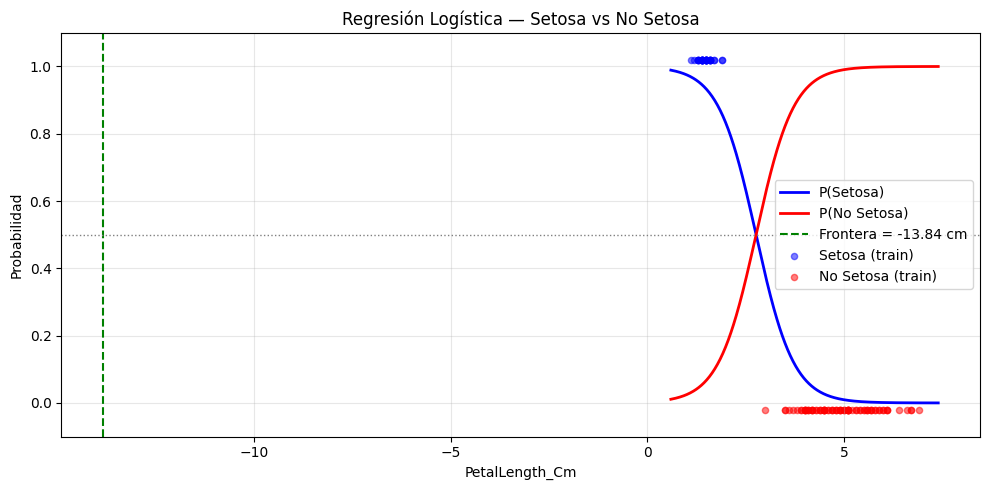

In [53]:
# Rango de valores para graficar (en escala original)
X_plot_orig = np.linspace(X_train_bin.min() - 0.5, X_train_bin.max() + 0.5, 500).reshape(-1, 1)
X_plot_s    = scaler_bin.transform(X_plot_orig)
prob_plot   = log_reg.predict_proba(X_plot_s)

plt.figure(figsize=(10, 5))

# Curvas de probabilidad
plt.plot(X_plot_orig, prob_plot[:, 1], 'b-', linewidth=2, label='P(Setosa)')
plt.plot(X_plot_orig, prob_plot[:, 0], 'r-', linewidth=2, label='P(No Setosa)')

# Frontera de decisión
plt.axvline(decision_boundary_original[0, 0], color='green', linestyle='--',
            linewidth=1.5, label=f'Frontera = {decision_boundary_original[0,0]:.2f} cm')
plt.axhline(0.5, color='gray', linestyle=':', linewidth=1)

# Datos reales
plt.scatter(X_train_bin[y_train_bin == 1], np.ones(y_train_bin.sum()) * 1.02,
            c='blue', s=20, alpha=0.5, label='Setosa (train)')
plt.scatter(X_train_bin[y_train_bin == 0], np.zeros((y_train_bin == 0).sum()) - 0.02,
            c='red', s=20, alpha=0.5, label='No Setosa (train)')

plt.xlabel('PetalLength_Cm')
plt.ylabel('Probabilidad')
plt.title('Regresión Logística — Setosa vs No Setosa')
plt.legend(loc='center right')
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Multiclasificador (Setosa, Versicolor, Virginica)

Estrategia **One-vs-Rest (OvR)**: se entrena un clasificador por clase, cada uno contra todas las demás.

sklearn implementa esto automáticamente con `multi_class='ovr'`.

In [54]:
# Preparar datos multiclase con todas las características
X_train_multi = strat_train_set[cols_features].values
y_train_multi = strat_train_set['Target'].values

X_test_multi  = strat_test_set[cols_features].values
y_test_multi  = strat_test_set['Target'].values

# Normalizar
scaler_multi = StandardScaler()
X_train_multi_s = scaler_multi.fit_transform(X_train_multi)
X_test_multi_s  = scaler_multi.transform(X_test_multi)

# Multiclasificador con One-vs-Rest
log_reg_multi = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42)
log_reg_multi.fit(X_train_multi_s, y_train_multi)

y_pred_multi = log_reg_multi.predict(X_test_multi_s)
print(f'Accuracy en Test: {accuracy_score(y_test_multi, y_pred_multi):.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test_multi, y_pred_multi,
                             target_names=iris.target_names))

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

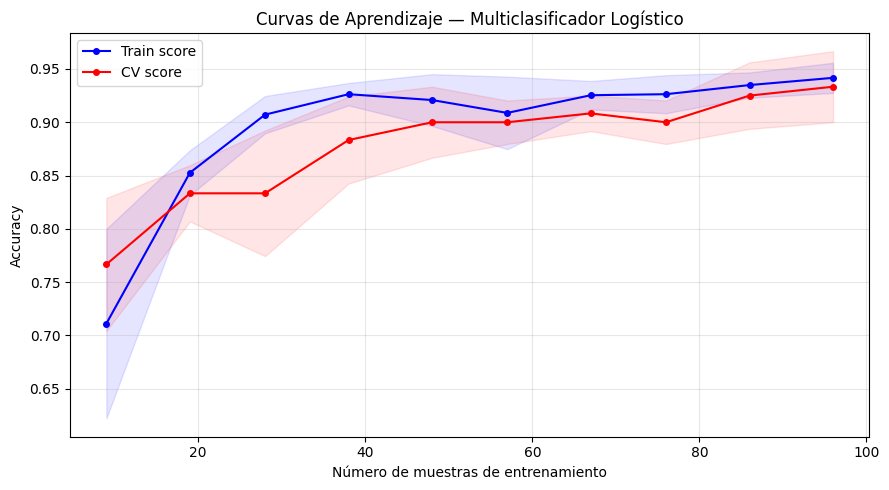

In [ ]:
# Curvas de aprendizaje del multiclasificador
from sklearn.model_selection import learning_curve

train_sizes, train_scores, cv_scores = learning_curve(
    LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42),
    X_train_multi_s, y_train_multi,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean    = cv_scores.mean(axis=1)
cv_std     = cv_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, cv_mean - cv_std,    cv_mean + cv_std,    alpha=0.1, color='red')
plt.plot(train_sizes, train_mean, 'b-o', ms=4, label='Train score')
plt.plot(train_sizes, cv_mean,    'r-o', ms=4, label='CV score')
plt.xlabel('Número de muestras de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curvas de Aprendizaje — Multiclasificador Logístico')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Predecir la clase de una nueva flor

Dada X = [4.9, 5.0, 1.8, 0.3] con características [SepalLength, SepalWidth, PetalLength, PetalWidth]

In [ ]:
# Código del lab
X_nueva = np.array([[4.9, 5.0, 1.8, 0.3]])
X_nueva_s = scaler_multi.transform(X_nueva)

# Probabilidades para cada clase
probabilidades = log_reg_multi.predict_proba(X_nueva_s)
clase_predicha = log_reg_multi.predict(X_nueva_s)

print('Características de la flor: SepalLength=4.9, SepalWidth=5.0, PetalLength=1.8, PetalWidth=0.3')
print()
for i, (nombre, prob) in enumerate(zip(iris.target_names, probabilidades[0])):
    print(f'P(y={nombre:12s}) = {prob:.4f} ({prob*100:.2f}%)')

print(f'\nClase predicha: {iris.target_names[clase_predicha[0]]}')

Características de la flor: SepalLength=4.9, SepalWidth=5.0, PetalLength=1.8, PetalWidth=0.3

P(y=setosa      ) = 0.9984 (99.84%)
P(y=versicolor  ) = 0.0016 (0.16%)
P(y=virginica   ) = 0.0000 (0.00%)

Clase predicha: setosa


# Reto Opcional — Clasificación de Pulsares (HTRU2 Dataset)

**Dataset:** https://archive.ics.uci.edu/ml/datasets/HTRU2

Contiene 8 características de señales de radio astronómicas. La clase 1 indica un pulsar real, la clase 0 es ruido de fondo.

In [ ]:
# Paso 1: Cargar el dataset desde la web
url_pulsar = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
              '00372/HTRU2.zip')

# Alternativa directa si el ZIP no está disponible:
# Descargar HTRU_2.csv manualmente desde la URL y leer con:
# df_p = pd.read_csv('HTRU_2.csv', header=None)

import urllib.request
import zipfile
import io

try:
    with urllib.request.urlopen(url_pulsar) as resp:
        z = zipfile.ZipFile(io.BytesIO(resp.read()))
        with z.open('HTRU_2.csv') as f:
            df_p = pd.read_csv(f, header=None)

    col_pulsar = ['MeanIP', 'StdIP', 'KurtosisIP', 'SkewnessIP',
                  'MeanDMSNR', 'StdDMSNR', 'KurtosisDMSNR', 'SkewnessDMSNR', 'Target']
    df_p.columns = col_pulsar

    print('Dataset cargado correctamente')
    print('Shape:', df_p.shape)
    print('Distribución de clases:')
    print(df_p['Target'].value_counts())
    df_p.head()

except Exception as e:
    print(f'No se pudo cargar el dataset automáticamente: {e}')
    print('Descarga HTRU_2.csv manualmente desde:')
    print('https://archive.ics.uci.edu/ml/datasets/HTRU2')
    print('y lee con: df_p = pd.read_csv("HTRU_2.csv", header=None)')

Dataset cargado correctamente
Shape: (17898, 9)
Distribución de clases:
Target
0    16259
1     1639
Name: count, dtype: int64


In [ ]:
# Paso 2: Dividir en Train y Test
from sklearn.model_selection import train_test_split

try:
    features_p = [c for c in df_p.columns if c != 'Target']
    X_p = df_p[features_p].values
    y_p = df_p['Target'].values

    X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
        X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)

    print(f'Train: {len(X_p_train)}  |  Test: {len(X_p_test)}')
except NameError:
    print('Primero carga el dataset en la celda anterior')

Train: 14318  |  Test: 3580


In [ ]:
# Paso 3: Normalizar y entrenar el algoritmo
try:
    scaler_p = StandardScaler()
    X_p_train_s = scaler_p.fit_transform(X_p_train)
    X_p_test_s  = scaler_p.transform(X_p_test)

    log_reg_p = LogisticRegression(max_iter=1000, random_state=42)
    log_reg_p.fit(X_p_train_s, y_p_train)

    y_p_pred = log_reg_p.predict(X_p_test_s)

    print(f'Accuracy: {accuracy_score(y_p_test, y_p_pred):.4f}')
    print('\nReporte de clasificación:')
    print(classification_report(y_p_test, y_p_pred,
                                 target_names=['No Pulsar', 'Pulsar']))
except NameError:
    print('Primero ejecuta los pasos anteriores')

Accuracy: 0.9796

Reporte de clasificación:
              precision    recall  f1-score   support

   No Pulsar       0.98      1.00      0.99      3252
      Pulsar       0.94      0.83      0.88       328

    accuracy                           0.98      3580
   macro avg       0.96      0.91      0.94      3580
weighted avg       0.98      0.98      0.98      3580



In [ ]:
# Paso 4 y 5: Curvas de aprendizaje y predicciones (ya incluidas arriba)
# Paso 5 extra: Regularización — comparar diferentes valores de C
try:
    C_values = [0.01, 0.1, 1, 10, 100]
    print('Efecto de la regularización (C) en el accuracy de Test:')
    print(f'{"C":>8}  {"Train Acc":>10}  {"Test Acc":>10}')
    print('-' * 35)
    for C in C_values:
        lr_c = LogisticRegression(C=C, max_iter=1000, random_state=42)
        lr_c.fit(X_p_train_s, y_p_train)
        acc_train = accuracy_score(y_p_train, lr_c.predict(X_p_train_s))
        acc_test  = accuracy_score(y_p_test,  lr_c.predict(X_p_test_s))
        print(f'{C:>8.2f}  {acc_train:>10.4f}  {acc_test:>10.4f}')

    print('\nNota: C pequeño = mayor regularización (penaliza coeficientes grandes)')
    print('      C grande  = menor regularización  (puede causar overfitting)')
except NameError:
    print('Primero ejecuta los pasos anteriores')

Efecto de la regularización (C) en el accuracy de Test:
       C   Train Acc    Test Acc
-----------------------------------
    0.01      0.9724      0.9768
    0.10      0.9764      0.9791
    1.00      0.9786      0.9796
   10.00      0.9792      0.9799
  100.00      0.9791      0.9799

Nota: C pequeño = mayor regularización (penaliza coeficientes grandes)
      C grande  = menor regularización  (puede causar overfitting)
